In [60]:
from pathlib import Path
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

import xclimate as xclim

In [82]:
# Variables to load
VARIABLES = [
    "TLAI_month_1",
    "RAIN_FROM_ATM_month_1",
]

# Time period for analysis
START_TIME = "1950-01"
END_TIME = "2014-12"

# Load grid
grid = xclim.load_fhist_ppe_grid().compute()

print(f"Loading variables from {START_TIME} to {END_TIME}...")
data = {}

for v in VARIABLES:
    print(f"  Loading {v}...")
    name = "_".join(v.split("_")[:-2])

    data[v] = (
        xclim.load_fhist(v, keep_var_only=True)[name]
        .sel(lat=slice(-60, None), time=slice(START_TIME, END_TIME))
        .reindex_like(grid, method="nearest", tolerance=1e-3)
    )

# Mask out glaciated gridpoints without any plants (PCT_GLAC>80 and LAI=0)
min_lai = data['TLAI_month_1'].min(dim=['member', 'time'])
mask = xr.where((min_lai < 0) & (grid.PCT_GLC >= 80), 0, 1)

Loading variables from 1950-01 to 2014-12...
  Loading TLAI_month_1...
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27


/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 27
  result = blockwise(


  Loading RAIN_FROM_ATM_month_1...
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27]
27


/glade/work/bbuchovecky/miniforge3/envs/data-sci-py312/lib/python3.12/site-packages/dask/array/core.py:5198: PerformanceWarning: Increasing number of chunks by factor of 27
  result = blockwise(


In [83]:
data['RAIN_FROM_ATM_month_1']

<xarray.DataArray 'RAIN_FROM_ATM' (member: 27, time: 780, lat: 96, lon: 144)> Size: 1GB
dask.array<where, shape=(27, 780, 96, 144), dtype=float32, chunksize=(1, 1, 96, 144), chunktype=numpy.ndarray>
Coordinates:
  * member   (member) int64 216B 0 1 2 3 4 5 6 7 8 ... 20 21 22 23 24 25 26 27
  * time     (time) object 6kB 1950-01-01 00:00:00 ... 2014-12-01 00:00:00
  * lat      (lat) float64 768B -90.0 -88.11 -86.21 -84.32 ... 86.21 88.11 90.0
  * lon      (lon) float64 1kB 0.0 2.5 5.0 7.5 10.0 ... 350.0 352.5 355.0 357.5
Attributes:
    long_name:     atmospheric rain received from atmosphere (pre-repartition...
    units:         mm/s
    cell_methods:  time: mean

In [64]:
lai = data["TLAI_month_1"].sel(member=0)

climlai = lai.groupby('time.month').mean().compute()

climlai_max = climlai.max(dim='month')
climlai_rng = climlai.max(dim='month') - climlai.min(dim='month')

laithresh = climlai_max - 0.5 * climlai_rng

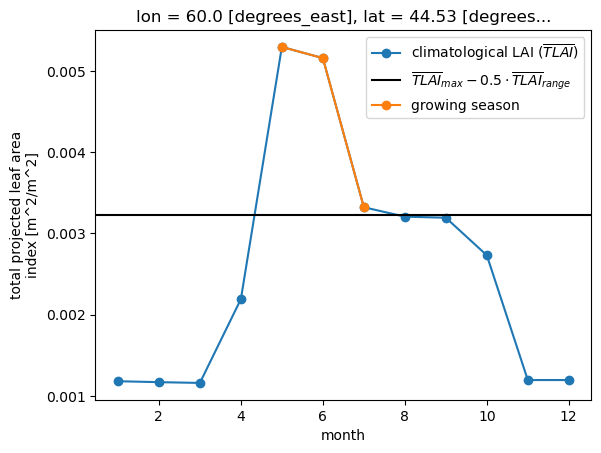

In [74]:
gc_lat = 45
gc_lon = 60

gc = dict(lat=gc_lat, lon=gc_lon, method='nearest')

# fig = plt.figure(dpi=200)
climlai.sel(**gc).plot(marker='o', label='climatological LAI ($\\overline{TLAI}$)')
plt.axhline(laithresh.sel(**gc), c='k', label='$\\overline{TLAI}_{max} - 0.5 \\cdot \\overline{TLAI}_{range}$')
climlai.sel(**gc).where(climlai.sel(**gc) >= laithresh.sel(**gc)).plot(marker='o', label='growing season')
plt.legend()

In [81]:
grsn_mask = climlai >= laithresh

da = lai

grsn_da = da.assign_coords(month=('time', da.time.dt.month.values))
grsn_da_ym = (
    grsn_da.assign_coords(year=('time', da.time.dt.year.values))
    .set_index(time=['year', 'month'])
    .unstack('time')
    .transpose('year', 'month', 'lat', 'lon')
)
grsn_da_masked = grsn_da_ym.where(grsn_mask).transpose('year', 'month', 'lat', 'lon')
grsn_da_annual = grsn_da_masked.mean(dim='month', skipna=True).transpose('year', 'lat', 'lon')
grsn_da_tmean = grsn_da_annual.mean(dim='year').compute()

print(f"grsn_da:        {grsn_da.dims} {grsn_da.shape}")
print(f"grsn_da_ym:     {grsn_da_ym.dims} {grsn_da_ym.shape}")
print(f"grsn_da_masked: {grsn_da_masked.dims} {grsn_da_masked.shape}")
print(f"grsn_da_annual: {grsn_da_annual.dims} {grsn_da_annual.shape}")
print(f"grsn_da_tmean: {grsn_da_tmean.dims} {grsn_da_tmean.shape}")

grsn_da:        ('time', 'lat', 'lon') (780, 96, 144)
grsn_da_ym:     ('year', 'month', 'lat', 'lon') (65, 12, 96, 144)
grsn_da_masked: ('year', 'month', 'lat', 'lon') (65, 12, 96, 144)
grsn_da_annual: ('year', 'lat', 'lon') (65, 96, 144)
grsn_da_tmean: ('lat', 'lon') (96, 144)


Text(0.5, 1.0, '$LAI > 0.01$')

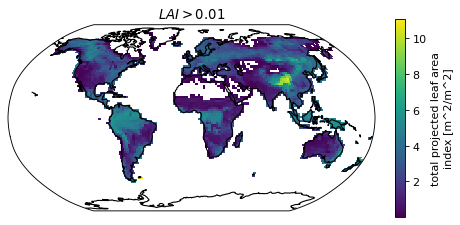

In [79]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson()}, dpi=80)
grsn_da_tmean.where(grsn_da_tmean > 0.01).plot(ax=ax, transform=ccrs.PlateCarree(), cbar_kwargs={'fraction': 0.025})
ax.coastlines()
ax.set_title('$LAI > 0.01$')

Text(0.5, 1.0, '$LAI > 0.15$')

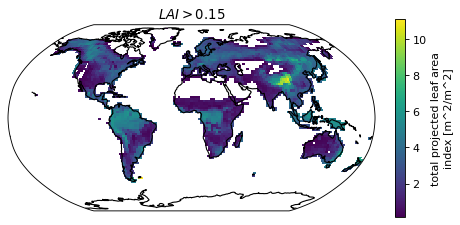

In [80]:
fig, ax = plt.subplots(subplot_kw={'projection': ccrs.Robinson()}, dpi=80)
grsn_da_tmean.where(grsn_da_tmean > 0.15).plot(ax=ax, transform=ccrs.PlateCarree(), cbar_kwargs={'fraction': 0.025})
ax.coastlines()
ax.set_title('$LAI > 0.15$')